# Similarity-Pruned Dataset Workflow

Select one random anchor graph, compute vectorized embeddings for all graphs,
define a regression target as cosine similarity to that anchor,
remove the top-`k` most similar graphs, and continue with the pruned dataset.


In [ ]:
%matplotlib inline
import math
import hashlib
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

from coco_grape.visualizer.mol_display import draw_molecules

try:
    from notebooks.notebook_utils import plot_similarity_distribution_with_iqr
except ModuleNotFoundError:
    from notebook_utils import plot_similarity_distribution_with_iqr


In [ ]:
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=3.5, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    if len(graphs) == 0:
        print("No graphs to display.")
        return

    if mode == 'molecule':
        draw_molecules(graphs)
        return

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)

    def lighten_color(color, amount):
        return tuple(channel + (1 - channel) * amount for channel in color[:3])

    def color_for_label(label):
        digest = hashlib.md5(str(label).encode("utf-8")).hexdigest()
        idx = (int(digest, 16) + color_offset) % cmap.N
        return lighten_color(cmap(idx), light)

    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1 or n_cols == 1:
        axes = np.array(axes).reshape(-1)
    else:
        axes = np.array(axes).reshape(-1)

    for i, graph in enumerate(graphs):
        ax = axes[i]
        labels = [graph.nodes[n].get('label', '?') for n in graph.nodes()]
        node_colors = [color_for_label(lbl) for lbl in labels]
        pos = nx.spring_layout(graph, seed=42)
        nx.draw_networkx(graph, pos=pos, node_color=node_colors, ax=ax, with_labels=show_label, font_size=8)
        ax.set_axis_off()

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()


def infer_display_mode(graphs):
    if globals().get('DATASET_TYPE') == 'MOLECULAR':
        return 'molecule'
    for graph in graphs[:5]:
        if any('symbol' in attrs or 'atomic_num' in attrs for _, attrs in graph.nodes(data=True)):
            return 'molecule'
    return 'not_molecule'


In [ ]:
# Configuration
DATASET_TYPE = 'MOLECULAR'  # 'MOLECULAR' or 'ARTIFICIAL'
DATASET_SIZE = 1600
RANDOM_STATE = 42
K_REMOVE = 5
REMOVE_ANCHOR = False
MAX_NODE_SIZE = 27

# Molecular loader config
ASSAY_ID = '651610'


In [ ]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        graph_copy = graph.copy()
        if target == 0:
            for u in graph_copy.nodes():
                graph_copy.nodes[u]['label'] += offset
        out_graphs.append(graph_copy)
    return out_graphs, targets


def build_dataset(dataset_size=200, artificial_size=5):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor

        alphabet_size = 3
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle',
            graph_generator_context_type_pos='cycle',
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree',
            target_size_pos=artificial_size,
            context_size_pos=artificial_size,
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=artificial_size,
            context_size_neg=artificial_size,
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size,
        ).sample(dataset_size // 2)
        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)
        return list(graphs), np.asarray(targets)

    if DATASET_TYPE == 'MOLECULAR':
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        from coco_grape.data_loader.loader import SupervisedDataSetLoader

        def pubchem_loader():
            return PubChemLoader().load(ASSAY_ID)

        original_graphs, original_targets = SupervisedDataSetLoader(
            pubchem_loader,
            size=dataset_size,
            use_equalized=False,
        ).load()

        original_graphs = np.asarray(original_graphs, dtype=object)
        original_targets = np.asarray(original_targets)

        keep_indices = [
            idx for idx, graph in enumerate(original_graphs)
            if nx.number_of_nodes(graph) <= MAX_NODE_SIZE
        ]
        graphs = original_graphs[keep_indices].tolist()
        targets = original_targets[keep_indices]
        return graphs, targets

    raise ValueError(f"Unsupported DATASET_TYPE: {DATASET_TYPE}")


In [ ]:
def compute_graph_embeddings(graphs, nbits=11):
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    embeddings = np.asarray(graph_vectorizer.fit_transform(graphs), dtype=np.float32)
    return graph_vectorizer, embeddings


def prune_by_anchor_similarity(graphs, targets, embeddings, k_remove=5, random_state=42, remove_anchor=False):
    if len(graphs) == 0:
        raise ValueError("Cannot prune an empty dataset.")
    if k_remove < 0:
        raise ValueError("k_remove must be >= 0.")
    if k_remove >= len(graphs):
        raise ValueError("k_remove must be smaller than the dataset size.")

    rng = np.random.default_rng(random_state)
    anchor_idx = int(rng.integers(low=0, high=len(graphs)))

    anchor_vec = embeddings[anchor_idx:anchor_idx + 1]
    similarity = cosine_similarity(embeddings, anchor_vec).ravel()

    ranking = np.argsort(-similarity)
    ordered = [idx for idx in ranking if (remove_anchor or idx != anchor_idx)]
    remove_indices = np.asarray(ordered[:k_remove], dtype=int)

    keep_mask = np.ones(len(graphs), dtype=bool)
    keep_mask[remove_indices] = False

    pruned_graphs = [g for g, keep in zip(graphs, keep_mask) if keep]
    pruned_targets = np.asarray([t for t, keep in zip(targets, keep_mask) if keep])
    pruned_similarity = similarity[keep_mask]

    removed_similarity = similarity[remove_indices]

    summary = pd.DataFrame({
        'graph_index': np.arange(len(graphs)),
        'target': targets,
        'cosine_to_anchor': similarity,
        'is_anchor': np.arange(len(graphs)) == anchor_idx,
        'removed': ~keep_mask,
    }).sort_values('cosine_to_anchor', ascending=False)

    return {
        'anchor_idx': anchor_idx,
        'anchor_graph': graphs[anchor_idx],
        'anchor_target': targets[anchor_idx],
        'similarity_target': similarity,
        'remove_indices': remove_indices,
        'removed_similarity': removed_similarity,
        'summary': summary,
        'pruned_graphs': pruned_graphs,
        'pruned_targets': pruned_targets,
        'pruned_similarity_target': pruned_similarity,
        'keep_mask': keep_mask,
    }


In [ ]:
graphs, targets = build_dataset(dataset_size=DATASET_SIZE)
print(f"Loaded graphs: {len(graphs)}")
if len(targets) > 0:
    bincount = np.bincount(np.asarray(targets, dtype=int)) if np.issubdtype(np.asarray(targets).dtype, np.integer) else None
    if bincount is not None:
        print(f"Class split: {bincount}")

graph_vectorizer, embeddings = compute_graph_embeddings(graphs, nbits=11)
print(f"Embeddings shape: {embeddings.shape}")

result = prune_by_anchor_similarity(
    graphs=graphs,
    targets=np.asarray(targets),
    embeddings=embeddings,
    k_remove=K_REMOVE,
    random_state=RANDOM_STATE,
    remove_anchor=REMOVE_ANCHOR,
)

print(f"Anchor index: {result['anchor_idx']} (target={result['anchor_target']})")
print(f"Removed graphs: {len(result['remove_indices'])}")
print(f"Remaining graphs: {len(result['pruned_graphs'])}")

display(result['summary'].head(12))



In [ ]:
display_mode = infer_display_mode(graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

removed_graphs = [graphs[i] for i in result['remove_indices']]
print(f"Removed top-{len(removed_graphs)} most similar graphs:")
plot_networkx_graphs(removed_graphs, n_cols=max(1, len(removed_graphs)), mode=display_mode)


In [ ]:
# Working dataset after similarity-based pruning
working_graphs = result['pruned_graphs']
working_targets = result['pruned_targets']
working_similarity_target = result['pruned_similarity_target']

print(f"working_graphs: {len(working_graphs)}")
print(f"working_targets: {len(working_targets)}")
print(f"working_similarity_target shape: {working_similarity_target.shape}")
print(f"cosine target range: [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")


## Strict CFG Experiment: Similarity to Hidden Target Graph

Train `EqMDecompositionalGraphGenerator` on the pruned dataset with the regression target
`working_similarity_target`, then generate with `desired_target=1.0` and `desired_target=0.7`
and compare average cosine similarity to the hidden anchor graph.


In [ ]:
import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents[:2]]:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package from current working directory.")

del _root, _root_str

from NSPPK.nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from eqm_decompositional_graph_generator.eqm_conditional_node_generator import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_generator import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)


In [ ]:
import dill as pickle

# CFG experiment configuration
GEN_NBITS = 11
GEN_VERBOSE = 2
GEN_MAX_EPOCHS = 120
GEN_BATCH_SIZE = 16
GEN_TOTAL_STEPS = 100

EVAL_N_SAMPLES = 8
EVAL_GUIDANCE_SCALE = 2.0
TARGET_HIGH = 1.0
TARGET_LOW = 0.65

# Early stopping: require a meaningful relative improvement on val_total
EARLY_STOPPING_RELATIVE_DELTA = 1e-3  # 0.1%
EARLY_STOPPING_REFERENCE_VAL_TOTAL = 5.2e4
EARLY_STOPPING_MIN_DELTA = EARLY_STOPPING_REFERENCE_VAL_TOTAL * EARLY_STOPPING_RELATIVE_DELTA


REPO_ROOT = next(
    candidate.resolve()
    for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / 'eqm_decompositional_graph_generator').exists()
)
MODEL_PATH = REPO_ROOT / '.artifacts' / 'saved_models' / 'similarity_graph_generator.pkl'


def save_graph_generator(graph_generator, model_path=MODEL_PATH):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(graph_generator, f)
    print(f"Saved graph generator to {model_path}")
    return model_path


def load_graph_generator(model_path=MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Saved generator model not found: {model_path}")
    with open(model_path, 'rb') as f:
        loaded_generator = pickle.load(f)
    print(f"Loaded graph generator from {model_path}")
    return loaded_generator


def build_similarity_graph_generator(nbits=11, verbose=1, maximum_epochs=120, batch_size=16, total_steps=100):
    node_graph_vectorizer = NodeNSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )

    feasibility_size = WithinRangeFeasibilityEstimatorFromNumericalFunction(
        numerical_function=lambda graph: len(graph),
        quantile=None,
    )
    feasibility_unlabeled_structure = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_valence = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_cycle = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_estimator = FeasibilityEstimator(
        [feasibility_size, feasibility_valence, feasibility_cycle, feasibility_unlabeled_structure]
    )

    conditional_node_generator_model = EqMDecompositionalNodeGenerator(
        latent_embedding_dimension=128,
        number_of_transformer_layers=4,
        transformer_attention_head_count=4,
        transformer_dropout=0.2,
        learning_rate=1e-4,
        maximum_epochs=maximum_epochs,
        batch_size=batch_size,
        total_steps=total_steps,
        lambda_degree_importance=1e3,
        lambda_node_exist_importance=5e2,
        lambda_node_label_importance=5e4,
        lambda_edge_label_importance=1e3,
        lambda_locality_importance=2e3,
        degree_temperature=1,
        eqm_sigma=0.2,
        sampling_step_size=0.05,
        langevin_noise_scale=0.0,
        verbose=verbose,
        verbose_epoch_interval=10,
        enable_early_stopping=True,
        early_stopping_monitor='val_total',
        early_stopping_mode='min',
        early_stopping_patience=20,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        restore_best_checkpoint=True,
        cfg_condition_dropout_prob=0.1,
        cfg_null_target_strategy='zero',
        target_classification_max_distinct=20,
    )

    graph_decoder = EqMDecompositionalGraphDecoder(verbose=verbose)

    return EqMDecompositionalGraphGenerator(
        graph_vectorizer=graph_vectorizer,
        node_graph_vectorizer=node_graph_vectorizer,
        conditional_node_generator_model=conditional_node_generator_model,
        graph_decoder=graph_decoder,
        verbose=verbose,
        locality_sample_fraction=0.5,
        locality_horizon=1,
        negative_sample_factor=1,
        locality_sampling_strategy='stratified_preserve',
        locality_target_positive_ratio=0.5,
        feasibility_estimator=feasibility_estimator,
        use_feasibility_filtering=True,
        max_feasibility_attempts=10,
        feasibility_candidates_per_attempt=4,
        feasibility_failure_mode='return_partial',
    )


def cosine_to_hidden_target(graphs_to_compare, hidden_graph, fitted_graph_vectorizer):
    if len(graphs_to_compare) == 0:
        return np.array([], dtype=float)
    hidden_embedding = np.asarray(fitted_graph_vectorizer.transform([hidden_graph]), dtype=np.float32)
    generated_embeddings = np.asarray(fitted_graph_vectorizer.transform(graphs_to_compare), dtype=np.float32)
    return cosine_similarity(generated_embeddings, hidden_embedding).ravel()


Epoch 100/120 | ETA 0h 03m 27s:
  train total=  52016.2 |        eqm   50004.9 96.1% |        deg     345.3  0.7% |      exist       0.9 <0.1% | node_label     134.7  0.3% | edge_label     135.7  0.3% |       edge    1394.7  2.7% | dominant=eqm (96.1%)
  val   total=  52097.9 |        eqm   49920.5 95.8% |        deg     379.8  0.7% |      exist       0.9 <0.1% | node_label     228.9  0.4% | edge_label     123.0  0.2% |       edge    1444.9  2.8% | dominant=eqm (95.8%)
Epoch 110/120 | ETA 0h 01m 53s:
  train total=  51851.7 |        eqm   49970.3 96.4% |        deg     325.9  0.6% |      exist       1.0 <0.1% | node_label      69.6  0.1% | edge_label     118.8  0.2% |       edge    1366.0  2.6% | dominant=eqm (96.4%)
  val   total=  51987.2 |        eqm   49937.3 96.1% |        deg     362.8  0.7% |      exist       1.4 <0.1% | node_label     129.9  0.2% | edge_label     161.4  0.3% |       edge    1394.6  2.7% | dominant=eqm (96.1%)
Epoch 120/120 | ETA 0h 00m 00s:
  train total=  5179

`Trainer.fit` stopped: `max_epochs=120` reached.


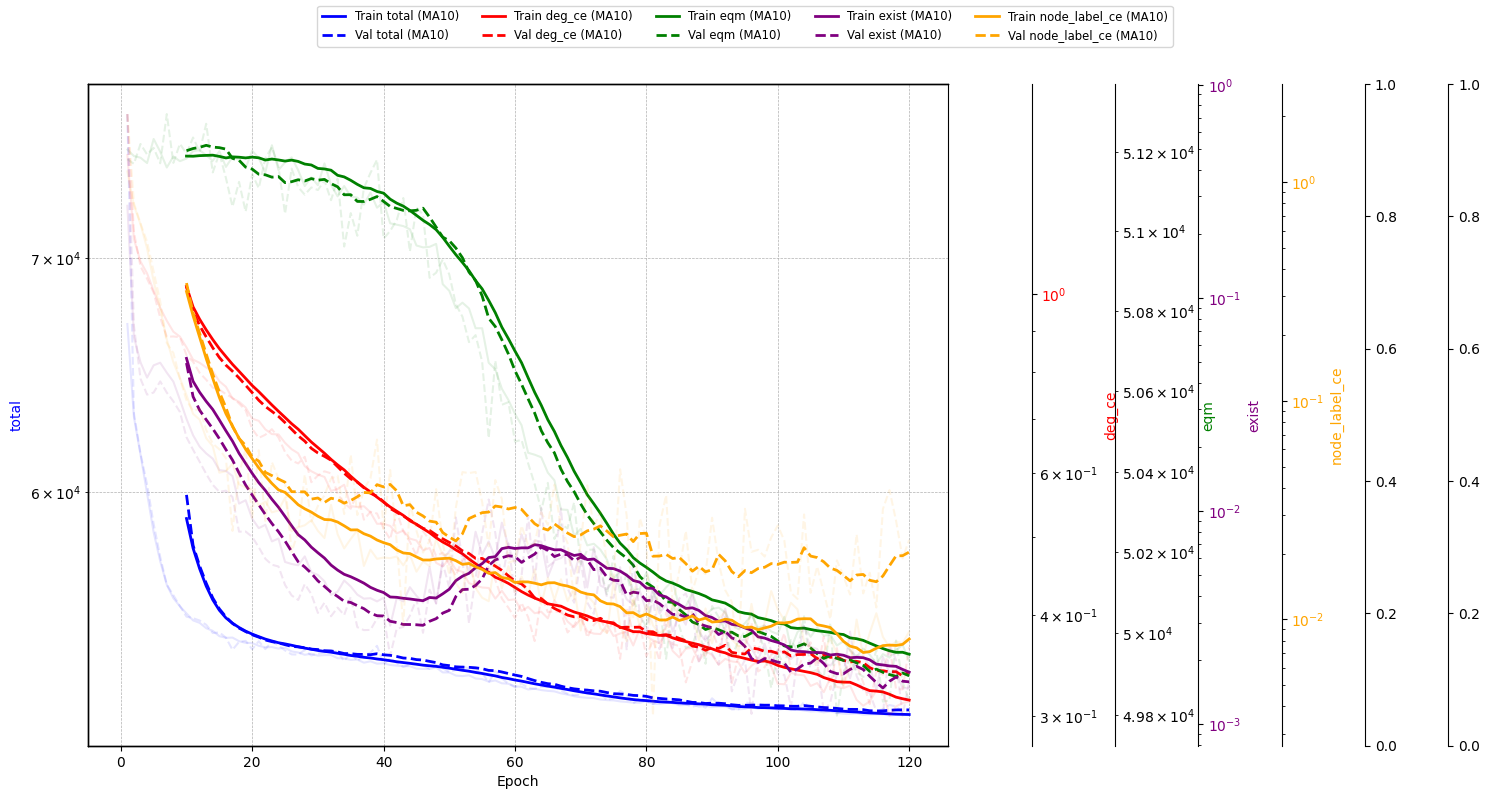

Restored best checkpoint from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_c9482fc749d842089172d5d08efad520/best-119-51750.9414.ckpt (best_epoch=120, val_total=51750.9414, stopped_epoch=121).
Saved graph generator to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl
CPU times: user 2h 27min 24s, sys: 16min 13s, total: 2h 43min 38s
Wall time: 23min 17s


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl')

In [11]:
%%time
similarity_graph_generator = build_similarity_graph_generator(
    nbits=GEN_NBITS,
    verbose=GEN_VERBOSE,
    maximum_epochs=GEN_MAX_EPOCHS,
    batch_size=GEN_BATCH_SIZE,
    total_steps=GEN_TOTAL_STEPS,
)

print(f"Training on {len(working_graphs)} pruned graphs with similarity targets in [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")
_ = similarity_graph_generator.fit(
    working_graphs,
    targets=working_similarity_target,
)

# Save trained generator
save_graph_generator(similarity_graph_generator)

In [ ]:
# Reload generator from disk before sampling
similarity_graph_generator = load_graph_generator(MODEL_PATH)

generated_high = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_HIGH,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=False,
)

generated_low = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_LOW,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=False,
)

# Similarity vectors for generated samples vs hidden target
sim_high = cosine_to_hidden_target(generated_high, result['anchor_graph'], graph_vectorizer)
sim_low = cosine_to_hidden_target(generated_low, result['anchor_graph'], graph_vectorizer)

# Plot + summary stats in one utility call
similarity_stats = plot_similarity_distribution_with_iqr(
    sim_high=sim_high,
    sim_low=sim_low,
    target_high=TARGET_HIGH,
    target_low=TARGET_LOW,
)


Loaded graph generator from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl


Anchor graph:


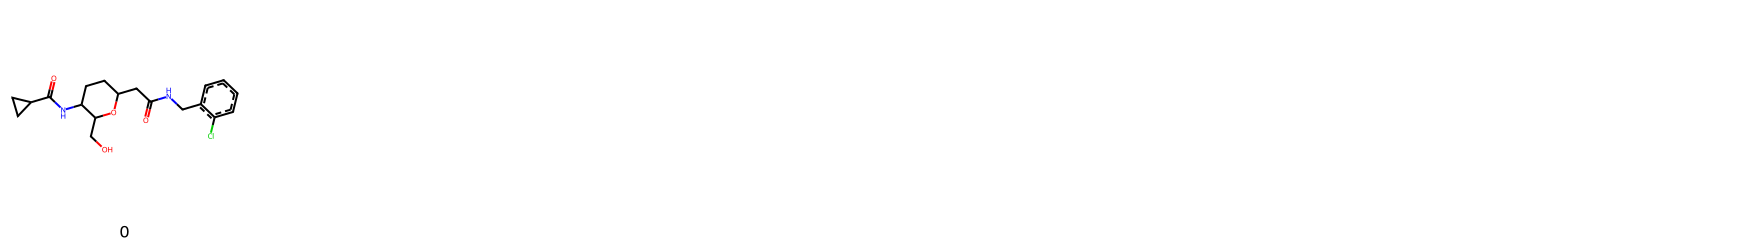

Sample generations for desired_target=1.0


NameError: name 'generated_high' is not defined

In [ ]:
display_mode = infer_display_mode(working_graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

print('Sample generations for desired_target=1.0')
plot_networkx_graphs(generated_high[:6], n_cols=min(6, max(1, len(generated_high[:6]))), mode=display_mode)

print('Sample generations for desired_target=0.7')
plot_networkx_graphs(generated_low[:6], n_cols=min(6, max(1, len(generated_low[:6]))), mode=display_mode)